# What do your blood sugars tell you?

## 📖 Background

Diabetes mellitus remains a global health issue, causing several thousand people to die each day from this single condition. Finding and avoiding diabetes in the earlier stages can help reduce the risk of serious health issues such as circulatory system diseases, kidney malfunction, and vision loss. This competition involves developing a predictive model for effectively detecting potential Diabetes cases, ideally, before commencing preventive treatment.


## 💾 The data

The dataset contains diagnostic measurements that are associated with diabetes, which were collected from a population of Pima Indian women. The data includes various medical and demographic attributes, making it a well-rounded resource for predictive modeling.

The columns and Data Types are as follows:

- Pregnancies
Type: Numerical (Continuous)
Description: Number of times the patient has been pregnant.

- Glucose
Type: Numerical (Continuous)
Description: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

- BloodPressure
Type: Numerical (Continuous)
Description: Diastolic blood pressure (mm Hg).

- SkinThickness
Type: Numerical (Continuous)
Description: Triceps skinfold thickness (mm).

- Insulin
Type: Numerical (Continuous)
Description: 2-Hour serum insulin (mu U/ml).

- BMI
Type: Numerical (Continuous)
Description: Body mass index (weight in kg/(height in m)^2).

- DiabetesPedigreeFunction
Type: Numerical (Continuous)
Description: A function that represents the likelihood of diabetes based on family history.

- Age
Type: Numerical (Continuous)
Description: Age of the patient in years.

- Outcome
Type: Categorical (Binary)
Description: Class variable (0 or 1) indicating whether the patient is diagnosed with diabetes. 1 = Yes, 0 = No.

In [1]:
import pandas as pd

data = pd.read_csv('data/diabetes.csv')
# Display the first few rows of the DataFrame
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Visualizing the data distribution of glucose

C:\Users\STUDSENT\AppData\Local\Temp\ipykernel_21680\1414646319.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=data, palette=["blue", "red"])


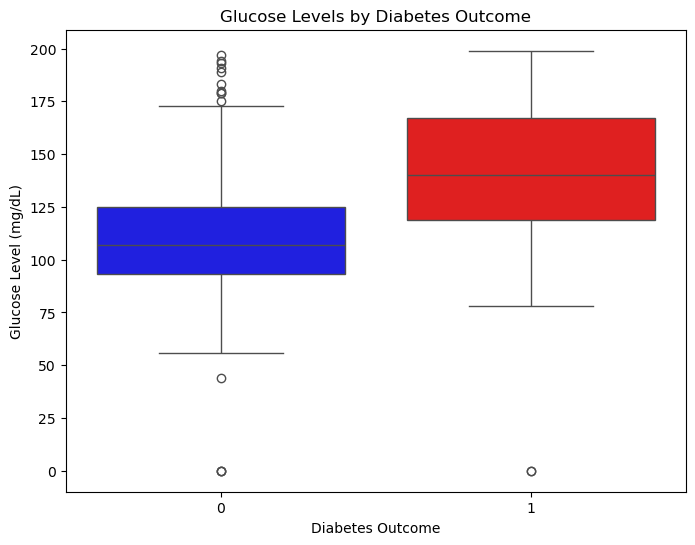

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Outcome' is treated as a categorical variable
data['Outcome'] = data['Outcome'].astype('category')

# Boxplot of Glucose levels by Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=data, palette=["blue", "red"])
plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose Level (mg/dL)")
plt.show()


#### Visualizing the age distribution

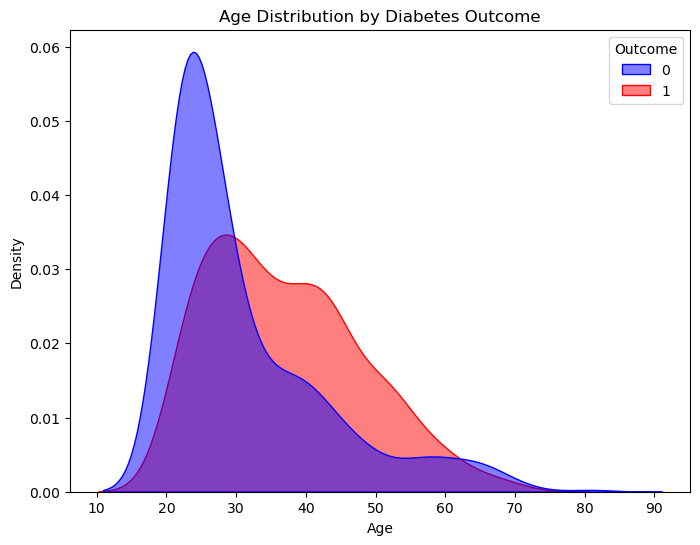

In [3]:
# Density plot of Age by Outcome
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x='Age', hue='Outcome', fill=True, common_norm=False, palette=["blue", "red"], alpha=0.5)
plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()


## 💪 Competition challenge

In this challenge, you will focus on the following key tasks:

- Determine the most important factors affecting the diabetes outcome.
- Create interactive plots to visualize the relationship between diabetes and the determined factors from the previous step.
- What's the risk of a person of Age 54, length 178 cm and weight 96 kg, and Glucose levels of 125 mg/dL getting diabetes?

## 🧑‍⚖️ Judging criteria

This is a community-based competition. Once the competition concludes, you'll have the opportunity to view and vote for the best submissions of others as the voting begins. The top 5 most upvoted entries will win. The winners will receive DataCamp merchandise.

## ✅ Checklist before publishing into the competition
- Rename your workspace to make it descriptive of your work. N.B. you should leave the notebook name as notebook.ipynb.
- **Remove redundant cells** like the judging criteria, so the workbook is focused on your story.
- Make sure the workbook reads well and explains how you found your insights. 
- Try to include an **executive summary** of your recommendations at the beginning.
- Check that all the cells run without error

## ⌛️ Time is ticking. Good luck!

In [16]:
# importing needed libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [5]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Determine the most important factors affecting the diabetes outcome.


# To determine the most important factors affecting diabetes outcomes, let's build a base model

# retrieving the explanatory and target variables
target_vars = data['Outcome']
explanatory_var = data.drop(columns=['Outcome'])

# let's split the data 
X_train, X_test, y_train, y_test = train_test_split(explanatory_var, target_vars, test_size=0.2, random_state=42)

# training the model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# measuring the accuracy score
accuracy = model.score(X_test, y_test)
print(f"The accuracy of the base model(Random Forest): {accuracy}")

The accuracy of the base model(Random Forest): 0.7467532467532467


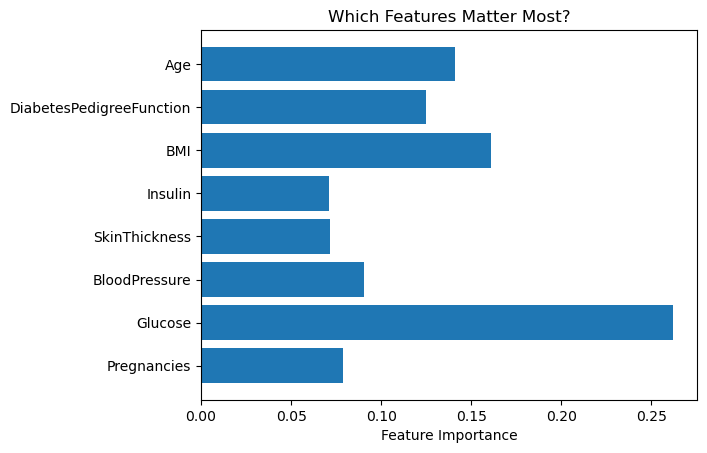

In [10]:
# let's get the important variables
importance_values = model.feature_importances_

columns = explanatory_var.columns

# Plot
plt.barh(columns, importance_values)
plt.xlabel("Feature Importance")
plt.title("Which Features Matter Most?")
plt.show()

In [19]:
# based on the base-model, let's train a different model to compare performance

# let's standardize the values
scaler = StandardScaler()
explanatory_var_scaled = scaler.fit_transform(explanatory_var)

# splitting the data
X_train_scaled, X_test_scaled, y_train_log, y_test_log = train_test_split(explanatory_var_scaled, target_vars, test_size=0.2, random_state=42)

# training the model: Logistic regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_log)

log_accuracy = log_model.score(X_test_scaled, y_test_log)
print(f"The accuracy of the Logistic Regression model: {log_accuracy}")

The accuracy of the Logistic Regression model: 0.7532467532467533


In [23]:
# Coefficients show the feature impact
import numpy as np

coef = log_model.coef_[0]  # LogisticRegression gives one coef per class

for feature, importance in zip(explanatory_var.columns, coef):
    print(f"{feature}: {importance:.4f}")


Pregnancies: 0.2162
Glucose: 1.0693
BloodPressure: -0.2587
SkinThickness: 0.0472
Insulin: -0.1990
BMI: 0.7924
DiabetesPedigreeFunction: 0.2271
Age: 0.4304


The base model was built using Random Forest, with Logistic Regression model to validate the features selected by the base model.
In terms of accuracy, both models performed fairly well, with an ~75% accuracy. The most important features affecting the diabetes
outcome returned by both model are Glucose, BMI and Age, which is expected. 